# DSN Mart sales prediction

DSN Bootcamp Qualification Hackathon 2026, ML track. The task is to predict `total_sales` for a product in a store, scored with RMSE.

Order: setup, EDA, decisions, cleaning, models, blend, submission, experiments that didn't make it, result.

## Setup

Tested locally and on Kaggle with the competition data attached. It should also run on Colab if `train.csv`, `test.csv` and `sample_submission.csv` are uploaded next to the notebook, but I haven't tested that.

The numbers quoted in the text come from my local run (macOS on Apple Silicon, XGBoost 2.1.4). On Kaggle, XGBoost gives slightly different trees even with the same version, so anything involving XGBoost can differ slightly there. For example the blend CV is 1067.87 instead of 1067.90.

In [1]:
import importlib.metadata, subprocess, sys

PINNED = {"xgboost": None, "catboost": None}
for pkg, version in PINNED.items():
    try:
        installed = importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        installed = None
    if installed is None or (version and installed != version):
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", f"{pkg}=={version}" if version else pkg], check=True)
print({pkg: importlib.metadata.version(pkg) for pkg in PINNED})

{'xgboost': '2.1.4', 'catboost': '1.2.10'}


In [2]:
import glob, os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

pd.set_option("display.width", 140)
candidates = ["data", ".", "/content"] + sorted({os.path.dirname(p) for p in glob.glob("/kaggle/input/**/train.csv", recursive=True)})
DATA = next((d for d in candidates if os.path.exists(os.path.join(d, "train.csv"))), None)
assert DATA is not None, "train.csv not found; attach the competition data or upload the CSVs"
TARGET = "total_sales"
SEEDS, FOLDS = [0, 1, 2], 5

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

train = pd.read_csv(f"{DATA}/train.csv")
test = pd.read_csv(f"{DATA}/test.csv")
sub = pd.read_csv(f"{DATA}/sample_submission.csv")
print(train.shape, test.shape)
train.head()

(6818, 13) (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


## EDA

### Basic checks

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [4]:
train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
product_weight_kg,5593.0,12.851,4.647,4.482,8.750,12.647,16.894,21.883
shelf_visibility,6818.0,0.066,0.052,0.000,0.027,0.053,0.093,0.320
product_price,6818.0,140.474,62.414,31.110,93.280,142.065,185.988,273.040
store_age_years,6818.0,34.178,8.385,23.000,28.000,33.000,45.000,47.000
total_sales,6818.0,2174.757,1697.895,32.700,834.792,1790.890,3092.587,12996.820


In [5]:
miss = pd.DataFrame({"train": train.isna().sum(), "test": test.isna().sum()})
miss[miss.sum(axis=1) > 0]

,train,test
product_weight_kg,1225,306.0
store_size,1919,491.0


Two columns have missing values: product weight (about 18%) and store size (about 28%).

In [6]:
train.groupby("store_code").store_size.apply(lambda s: s.isna().mean()).rename("share_missing_size")

store_code
STORE-7WS    0.0
STORE-89Z    0.0
STORE-9RG    0.0
STORE-AGY    0.0
STORE-DKU    1.0
STORE-HL7    0.0
STORE-JOR    1.0
STORE-OYG    1.0
STORE-T5G    0.0
STORE-YLW    0.0
Name: share_missing_size, dtype: float64

Store size is missing for whole stores, never for part of a store, so I can't fill it from other rows of the same store.

In [7]:
print(train.groupby("store_code")[["store_size", "store_format", "store_location_tier", "store_age_years"]].nunique().max())
train.groupby("store_code")[["store_format", "store_location_tier", "store_age_years", "store_size"]].first()

store_size             1
store_format           1
store_location_tier    1
store_age_years        1
dtype: int64


,store_format,store_location_tier,store_age_years,store_size
store_code,,,,
STORE-7WS,Flagship Hypermarket,Tier_3,47,Medium
STORE-89Z,Standard Supermarket,Tier_1,33,Medium
STORE-9RG,Standard Supermarket,Tier_2,28,Small
STORE-AGY,Standard Supermarket,Tier_3,45,Large
STORE-DKU,Standard Supermarket,Tier_2,30,None
STORE-HL7,Superstore,Tier_3,23,Medium
STORE-JOR,Corner Shop,Tier_3,34,None
STORE-OYG,Standard Supermarket,Tier_2,25,None
STORE-T5G,Corner Shop,Tier_1,47,Small


Every store has one format, tier, age and size. With only 10 stores, all the store columns together carry no more information than `store_code`.

### Categorical columns

In [8]:
print(train.fat_content.value_counts(), "\n")
print(train.product_category.nunique(), "category spellings")
train.product_category.value_counts().head(12)

fat_content
Low Fat    4425
Regular    2393
Name: count, dtype: int64 

48 category spellings


product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
Name: count, dtype: int64

In [9]:
train.product_category.str.title().value_counts()

product_category
Fruits And Vegetables    1006
Snack Foods               933
Household                 740
Frozen Foods              675
Dairy                     554
Canned                    517
Baking Goods              516
Health And Hygiene        412
Soft Drinks               366
Meat                      339
Breads                    209
Hard Drinks               169
Others                    132
Starchy Foods             113
Breakfast                  85
Seafood                    52
Name: count, dtype: int64

The categories are written in three cases ("Dairy", "DAIRY", "dairy"). After title-casing, 48 spellings collapse to 16 real categories.

### Products and stores in train vs test

In [10]:
print("products in train:", train.product_code.nunique())
print("share of test products also in train:", round(test.product_code.isin(train.product_code).mean(), 4))
pairs = set(zip(train.product_code, train.store_code))
print("share of test (product, store) pairs in train:", np.mean([p in pairs for p in zip(test.product_code, test.store_code)]))
print(train.product_code.value_counts().value_counts().sort_index().rename("products with n rows"))

products in train: 1555
share of test products also in train: 0.9965
share of test (product, store) pairs in train: 0.0
count
1     46
2    140
3    251
4    394
5    351
6    240
7     97
8     35
9      1
Name: products with n rows, dtype: int64


Almost every test product appears in train, but never in the same store. So a product's history in other stores is the only product-level information available. Most products have only 3 to 6 rows, which isn't much.

### Target

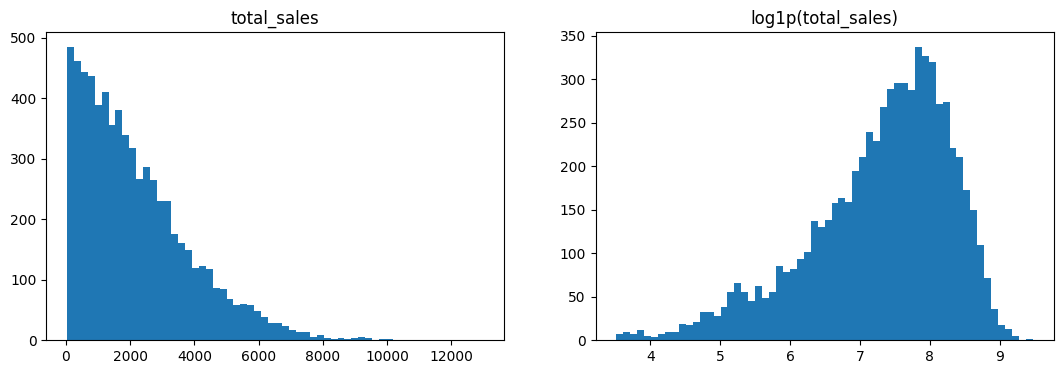

skew: 1.15


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(train.total_sales, bins=60)
ax[0].set_title("total_sales")
ax[1].hist(np.log1p(train.total_sales), bins=60)
ax[1].set_title("log1p(total_sales)")
plt.show()
print("skew:", round(train.total_sales.skew(), 2))

Sales are right-skewed. A transformed target is often used for this, but the metric is RMSE on raw sales, so I start with the raw target and compare a sqrt target in the experiments section.

### Sales against the features

In [12]:
num = ["product_weight_kg", "shelf_visibility", "product_price", "store_age_years"]
train[num + [TARGET]].corr()[TARGET].round(3)

product_weight_kg    0.016
shelf_visibility    -0.118
product_price        0.570
store_age_years      0.039
total_sales          1.000
Name: total_sales, dtype: float64

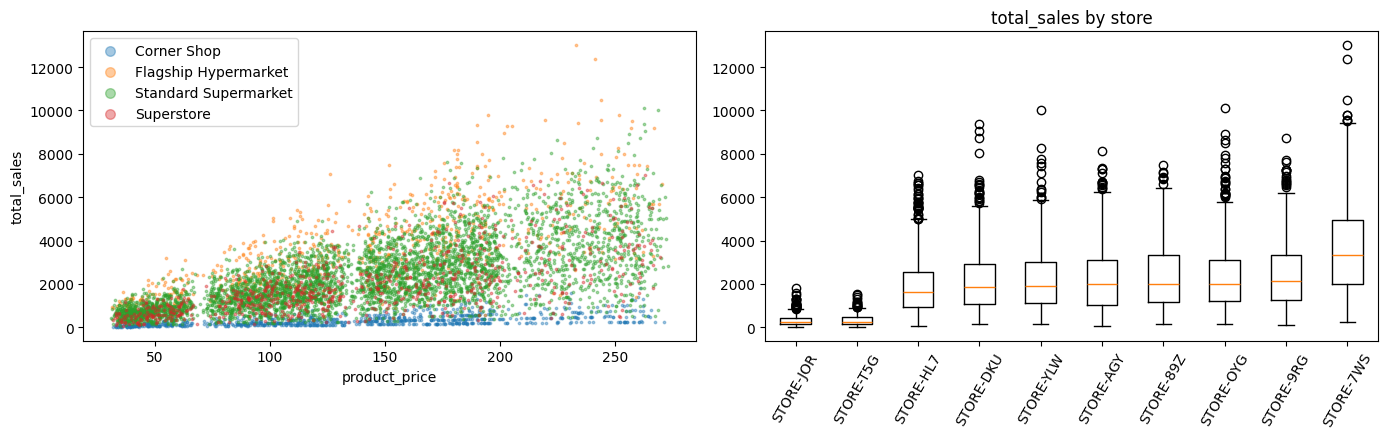

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for fmt, d in train.groupby("store_format"):
    ax[0].scatter(d.product_price, d.total_sales, s=3, alpha=.4, label=fmt)
ax[0].set_xlabel("product_price")
ax[0].set_ylabel("total_sales")
ax[0].legend(markerscale=4)
order = train.groupby("store_code").total_sales.median().sort_values().index
ax[1].boxplot([train.loc[train.store_code == s, TARGET] for s in order], labels=order)
ax[1].tick_params(axis="x", rotation=60)
ax[1].set_title("total_sales by store")
plt.tight_layout()
plt.show()

Price has by far the strongest correlation with sales (0.57). Visibility is next at -0.12, and weight and store age are close to 0.
The scatter is fan-shaped: sales spread out as price rises, and each store type sits at a different level, with corner shops at the bottom and the flagship hypermarket at the top.

This suggests looking at sales divided by price, which is roughly the number of units sold.

In [14]:
t = train.assign(units=train.total_sales / train.product_price)
t.groupby("store_code").agg(format=("store_format", "first"), tier=("store_location_tier", "first"),
                            rows=("units", "size"), mean_units=("units", "mean"),
                            std_units=("units", "std")).round(2).sort_values("mean_units")

,format,tier,rows,mean_units,std_units
store_code,,,,,
STORE-JOR,Corner Shop,Tier_3,439,2.39,1.40
STORE-T5G,Corner Shop,Tier_1,427,2.46,1.43
STORE-HL7,Superstore,Tier_3,742,13.85,6.62
STORE-DKU,Standard Supermarket,Tier_2,736,15.66,6.95
STORE-AGY,Standard Supermarket,Tier_3,748,15.95,7.29
STORE-YLW,Standard Supermarket,Tier_1,754,16.10,7.31
STORE-OYG,Standard Supermarket,Tier_2,744,16.65,7.15
STORE-89Z,Standard Supermarket,Tier_1,728,16.82,7.14
STORE-9RG,Standard Supermarket,Tier_2,752,17.15,7.34


In [15]:
t["price_band"] = pd.qcut(t.product_price, 8)
t.groupby("price_band", observed=True).units.agg(["mean", "std", "size"]).round(2)

,mean,std,size
price_band,,,
"(31.108999999999998, 57.512]",14.98,9.25,853
"(57.512, 93.28]",15.57,9.15,853
"(93.28, 113.714]",15.42,9.45,851
"(113.714, 142.065]",15.25,9.03,852
"(142.065, 163.942]",15.46,8.89,852
"(163.942, 185.988]",15.97,9.60,852
"(185.988, 222.514]",15.50,9.17,852
"(222.514, 273.04]",15.36,8.74,853


Units sold barely change with price (15.0 to 16.0 across the price bands), but they change a lot between stores: about 2.4 at the corner shops, 13.9 at the superstore, 15.7 to 17.2 at the standard supermarkets and 26.4 at the flagship.
So the core of the problem is sales ≈ price × (units for that store).

The spread of units within a store is large (standard deviation 6.6 to 7.3 at the supermarkets). To see how much of the error is left after the store effect, I fit store average units × price on all of train and score it on the same rows. This is an optimistic, in-sample number.

In [16]:
k_all = t.groupby("store_code").units.transform("mean")
print("in-sample RMSE of store average units x price:", round(rmse(t.total_sales, k_all * t.product_price), 1))

in-sample RMSE of store average units x price: 1070.1


Even fitted in-sample, store × price leaves an RMSE of about 1070, so most of the remaining error looks like noise. The other columns would have to explain a lot of it to make a real difference, which is what I check next.

### Do the other columns explain units?

In [17]:
t["units_rel"] = t.units / t.groupby("store_code").units.transform("mean")
for col in ["product_category", "fat_content"]:
    display(t.groupby(t[col].str.title()).units_rel.agg(["mean", "size"]).round(3).sort_values("mean"))
for col in ["shelf_visibility", "product_weight_kg"]:
    print(col, "corr with relative units:", round(t[[col, "units_rel"]].corr().iloc[0, 1], 3))

,mean,size
product_category,,
Breakfast,0.923,85
Dairy,0.977,554
Others,0.988,132
Frozen Foods,0.989,675
Hard Drinks,0.989,169
Soft Drinks,0.993,366
Snack Foods,0.995,933
Fruits And Vegetables,0.998,1006
Baking Goods,1.003,516


,mean,size
fat_content,,
Low Fat,0.997,4425
Regular,1.006,2393


shelf_visibility corr with relative units: 0.004
product_weight_kg corr with relative units: -0.01


After dividing out the store average, category, fat content, visibility and weight explain very little. Most category means sit between 0.98 and 1.02. The two extremes, Breakfast (0.92) and Seafood (1.05), are the two smallest categories, so they're probably noise too.
I keep these columns for the tree models, but I don't expect much from them.

### Shelf visibility zeros

In [18]:
print("rows with shelf_visibility == 0:", (train.shelf_visibility == 0).sum())
print("mean relative units, zero vs non-zero visibility:")
t.groupby(t.shelf_visibility == 0).units_rel.mean().round(3)

rows with shelf_visibility == 0: 422
mean relative units, zero vs non-zero visibility:


shelf_visibility
False    0.998
True     1.026
Name: units_rel, dtype: float64

A product on sale must take up some shelf space, so I treat a visibility of 0 as a recording error and replace it with that product's average visibility in other rows. Those rows sell about the same as the rest (relative units 1.03 vs 1.00), so nothing special seems to be going on with them.

### Price varies for the same product

rows per product: 5.47 | distinct prices per product: 5.46


kurtosis of the deviation: 0.08

relative deviation from product mean, percentiles 1/50/99: [-0.0452  0.0002  0.045 ]


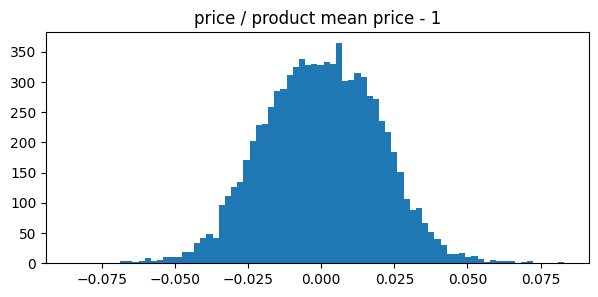

In [19]:
both = pd.concat([train, test])
pg = both.groupby("product_code").product_price
rel_dev = both.product_price / both.product_code.map(pg.mean()) - 1
print("rows per product:", round(both.groupby("product_code").size().mean(), 2),
      "| distinct prices per product:", round(pg.nunique().mean(), 2))
print("kurtosis of the deviation:", round(rel_dev.kurt(), 2))
print("\nrelative deviation from product mean, percentiles 1/50/99:", np.percentile(rel_dev, [1, 50, 99]).round(4))
plt.figure(figsize=(7, 3))
plt.hist(rel_dev, bins=80)
plt.title("price / product mean price - 1")
plt.show()

A product appears in 5.47 rows on average and has 5.46 distinct prices, so its price is different in almost every row. The deviations stay within about ±5% of the product's mean and are roughly bell-shaped.
One explanation is noise added on top of one real price per product. If sales were generated from that real price, an estimate pooled over all of a product's rows (train and test, prices only, no target) should predict better than the row's own price.
I try two estimates, the mean and the midpoint of the lowest and highest price, and compare them by CV in model 1.

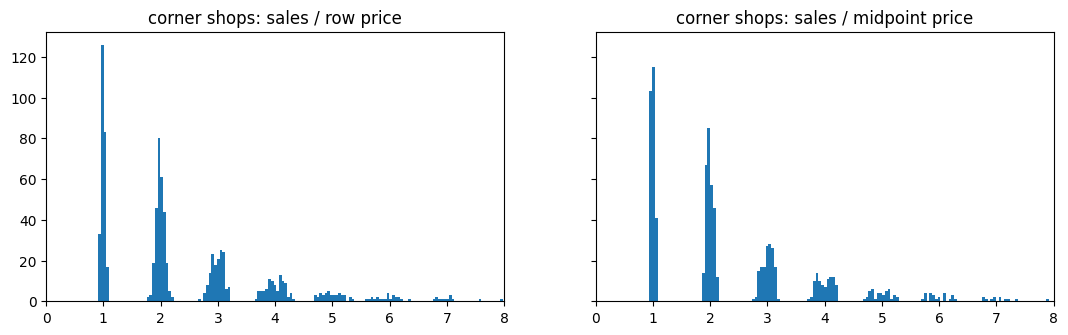

row price: share within 0.03 of a whole unit = 0.319
midpoint price: share within 0.03 of a whole unit = 0.334


In [20]:
true_price = (pg.max() + pg.min()) / 2
cs = train[train.store_format == "Corner Shop"]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
ax[0].hist(cs.total_sales / cs.product_price, bins=150)
ax[0].set_xlim(0, 8)
ax[0].set_title("corner shops: sales / row price")
ax[1].hist(cs.total_sales / cs.product_code.map(true_price), bins=150)
ax[1].set_xlim(0, 8)
ax[1].set_title("corner shops: sales / midpoint price")
plt.show()
for name, p in [("row price", cs.product_price), ("midpoint price", cs.product_code.map(true_price))]:
    u = cs.total_sales / p
    print(f"{name}: share within 0.03 of a whole unit = {((u - u.round()).abs() < 0.03).mean():.3f}")

At the corner shops, where units are small, sales divided by price bunch up at whole units (1, 2, 3, ...). With the midpoint price the bunching is a little tighter (33.4% of rows within 0.03 of a whole unit, against 31.9% with the row price).
That's consistent with one real price per product, but the gap is small, so I test it properly with CV in model 1.

## Decisions from the EDA

1. Model sales as store units × real price. This goes in as its own model, not just a feature.
2. Replace the row price with a per-product estimate (mean or midpoint), chosen by CV.
3. Add a per-product adjustment, shrunk heavily towards zero, because products have few rows and the noise is large.
4. Use CatBoost and XGBoost on the cleaned features to catch anything the simple model misses, then blend.
5. Validate with 5-fold CV repeated over 3 shuffles. The public leaderboard uses only about 850 rows, so I don't choose models by it.

## Cleaning and features for the tree models

In [21]:
df = pd.concat([train.drop(columns=[TARGET]), test], ignore_index=True)

df["product_category"] = df["product_category"].astype(str).str.strip().str.title()
fat = df["fat_content"].astype(str).str.strip().str.lower()
df["fat_content"] = np.where(fat.str.startswith("reg"), "Regular", "Low Fat")

df["weight_missing"] = df["product_weight_kg"].isna().astype(int)
df["product_weight_kg"] = df["product_weight_kg"].fillna(df.groupby("product_code")["product_weight_kg"].transform("mean"))
df["product_weight_kg"] = df["product_weight_kg"].fillna(df.groupby("product_category")["product_weight_kg"].transform("median"))

df["size_missing"] = df["store_size"].isna().astype(int)
mode = lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
df["store_size"] = df["store_size"].fillna(df.groupby("store_code")["store_size"].transform(mode))
df["store_size"] = df["store_size"].fillna(df.groupby("store_format")["store_size"].transform(mode))
df["store_size"] = df["store_size"].fillna("Unknown")

vis = df["shelf_visibility"].replace(0, np.nan)
df["vis_zero"] = (df["shelf_visibility"] == 0).astype(int)
df["shelf_visibility"] = vis.fillna(df.assign(v=vis).groupby("product_code")["v"].transform("mean")).fillna(vis.median())
df["vis_ratio_product"] = df["shelf_visibility"] / df.groupby("product_code")["shelf_visibility"].transform("mean")
df["vis_ratio_store"] = df["shelf_visibility"] / df.groupby("store_code")["shelf_visibility"].transform("mean")

df["price_per_kg"] = df["product_price"] / df["product_weight_kg"]
df["price_ratio_cat"] = df["product_price"] / df.groupby("product_category")["product_price"].transform("mean")
df["price_ratio_product"] = df["product_price"] / df.groupby("product_code")["product_price"].transform("mean")
df["log_price"] = np.log1p(df["product_price"])
df["price_pmean"] = df.groupby("product_code")["product_price"].transform("mean")
df["price_dev"] = df["product_price"] - df["price_pmean"]

df["product_n_stores"] = df.groupby("product_code")["store_code"].transform("count")
df["store_n_products"] = df.groupby("store_code")["product_code"].transform("count")
df["cat_n_in_store"] = df.groupby(["store_code", "product_category"])["id"].transform("count")

CATS = ["product_code", "fat_content", "product_category", "store_code", "store_size", "store_location_tier", "store_format"]
for c in CATS:
    df[c] = df[c].astype(str)
FEATS = [c for c in df.columns if c != "id"]

X = df.iloc[:len(train)][FEATS].reset_index(drop=True)
X_test = df.iloc[len(train):][FEATS].reset_index(drop=True)
y = train[TARGET].values

def as_category(frame):
    f = frame.copy()
    for c in CATS:
        f[c] = pd.Categorical(f[c], categories=sorted(df[c].unique()))
    return f

Xc, Xc_test = as_category(X), as_category(X_test)
XGB_FEATS = [c for c in FEATS if c != "product_code"]
print(len(FEATS), "features")

25 features


Missing weights are filled with the same product's weight from other rows, falling back to the category median. For store size I fill from the store, then the store format, then "Unknown". It doesn't matter much, since `store_code` already identifies the store.
XGBoost doesn't get `product_code` (1,559 levels in train and test). CatBoost gets it, because its ordered target statistics are designed for high-cardinality columns.

## Model 1: store units × price

- `k` is the average units sold per store (sales / midpoint price).
- The product adjustment is how far a product's sales sit above or below its store average, shrunk towards 0.
  With `alpha = 40`, a product seen in 4 stores keeps only about 10% of its raw deviation.

In [22]:
_pg = df.groupby("product_code")["product_price"]
TRUE_PRICE = (_pg.max() + _pg.min()) / 2

def structural_model(tr_idx, alpha):
    d = train.iloc[tr_idx]
    p = d.product_code.map(TRUE_PRICE).values
    k = pd.Series(d.total_sales.values / p).groupby(d.store_code.values).mean()
    r = d.total_sales.values / (d.store_code.map(k).values * p) - 1
    g = pd.DataFrame({"p": d.product_code.values, "r": r}).groupby("p").r.agg(["sum", "count"])
    eff = g["sum"] / (g["count"] + alpha)
    return lambda f: (f.store_code.map(k).values * f.product_code.map(TRUE_PRICE).values
                      * (1 + f.product_code.map(eff).fillna(0).values))

oof, preds = {}, {}
for alpha in [25, 40]:
    key = f"lin_a{alpha}"
    oof[key] = np.zeros(len(train))
    for s in SEEDS:
        for tr, va in KFold(FOLDS, shuffle=True, random_state=s).split(train):
            oof[key][va] += structural_model(tr, alpha)(train.iloc[va]) / len(SEEDS)
    preds[key] = structural_model(np.arange(len(train)), alpha)(test)
    print(f"{key}: CV RMSE {rmse(y, oof[key]):.3f}")

lin_a25: CV RMSE 1068.985
lin_a40: CV RMSE 1068.925


In [23]:
# how much each step adds, same folds
def cv_simple(price_col_fn, alpha=None):
    out = np.zeros(len(train))
    for s in SEEDS:
        for tr, va in KFold(FOLDS, shuffle=True, random_state=s).split(train):
            d, v = train.iloc[tr], train.iloc[va]
            p, pv = price_col_fn(d), price_col_fn(v)
            k = pd.Series(d.total_sales.values / p).groupby(d.store_code.values).mean()
            out[va] += v.store_code.map(k).values * pv / len(SEEDS)
    return rmse(y, out)

PMEAN_ONLY = _pg.mean()
print("store units x row price      ", round(cv_simple(lambda f: f.product_price.values), 2))
print("store units x mean price     ", round(cv_simple(lambda f: f.product_code.map(PMEAN_ONLY).values), 2))
print("store units x midpoint price ", round(cv_simple(lambda f: f.product_code.map(TRUE_PRICE).values), 2))
print("+ product adjustment (a=40)  ", round(rmse(y, oof["lin_a40"]), 2))

store units x row price       1071.44
store units x mean price      1070.62
store units x midpoint price  1070.31
+ product adjustment (a=40)   1068.93


Both pooled prices beat the row price, and the midpoint does slightly better than the mean, so model 1 uses the midpoint. The product adjustment gives the biggest single gain.

## Model 2: CatBoost and XGBoost

In [24]:
def fit_predict(name, tr, va, seed):
    if name == "cat_raw":
        m = CatBoostRegressor(iterations=5000, learning_rate=0.03, depth=6, l2_leaf_reg=5, loss_function="RMSE",
                              random_seed=seed, verbose=0, od_type="Iter", od_wait=300)
        m.fit(X.iloc[tr], y[tr], cat_features=CATS, eval_set=(X.iloc[va], y[va]))
        return m.predict(X.iloc[va]), m.predict(X_test)
    m = XGBRegressor(n_estimators=10000, learning_rate=0.01, max_depth=4, min_child_weight=20, subsample=0.8,
                     colsample_bytree=0.7, reg_lambda=5, enable_categorical=True, tree_method="hist",
                     early_stopping_rounds=300, random_state=seed)
    m.fit(Xc.iloc[tr][XGB_FEATS], y[tr], eval_set=[(Xc.iloc[va][XGB_FEATS], y[va])], verbose=False)
    return m.predict(Xc.iloc[va][XGB_FEATS]), m.predict(Xc_test[XGB_FEATS])

for name in ["cat_raw", "xgb_raw"]:
    oof[name], preds[name] = np.zeros(len(train)), np.zeros(len(test))
    for s in SEEDS:
        for tr, va in KFold(FOLDS, shuffle=True, random_state=s).split(X):
            p_va, p_te = fit_predict(name, tr, va, s)
            oof[name][va] += p_va / len(SEEDS)
            preds[name] += p_te / (len(SEEDS) * FOLDS)
    print(f"{name}: CV RMSE {rmse(y, oof[name]):.3f}")

cat_raw: CV RMSE 1071.153


xgb_raw: CV RMSE 1073.452


On their own, both tree models are worse than model 1. The blend below tests whether they still add something.

## Blend

Two ways to pick the weights: let an optimiser fit them on the out-of-fold predictions, or use round fixed weights (65% model 1 split evenly across both alphas, 35% trees split evenly).
Fitting weights on the same predictions they're scored on flatters them, so I also fit them on one half of the rows and score them on the other half, 20 times over.

In [25]:
from scipy.optimize import minimize

names = list(oof)
A = np.column_stack([oof[k] for k in names])
W = {"lin_a25": 0.325, "lin_a40": 0.325, "cat_raw": 0.175, "xgb_raw": 0.175}
w_fixed = np.array([W[k] for k in names])

def fit_weights(A, t):
    n = A.shape[1]
    res = minimize(lambda w: rmse(t, A @ w), np.full(n, 1 / n), method="SLSQP", bounds=[(0, 1)] * n,
                   constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return res.x

w_opt = fit_weights(A, y)
print("optimiser weights:", dict(zip(names, w_opt.round(3))))
print("in-sample   optimiser:", round(rmse(y, A @ w_opt), 3), "| fixed:", round(rmse(y, A @ w_fixed), 3))

opt_scores, fixed_scores, single_scores = [], [], []
for s in range(20):
    for a, b in KFold(2, shuffle=True, random_state=s).split(A):
        opt_scores.append(rmse(y[b], A[b] @ fit_weights(A[a], y[a])))
        fixed_scores.append(rmse(y[b], A[b] @ w_fixed))
        single_scores.append(rmse(y[b], oof["lin_a40"][b]))
print("held-out    optimiser:", round(np.mean(opt_scores), 3), "| fixed:", round(np.mean(fixed_scores), 3),
      "| model 1 alone:", round(np.mean(single_scores), 3))

optimiser weights: {'lin_a25': np.float64(0.628), 'lin_a40': np.float64(0.0), 'cat_raw': np.float64(0.236), 'xgb_raw': np.float64(0.137)}
in-sample   optimiser: 1067.841 | fixed: 1067.901
held-out    optimiser: 1068.858 | fixed: 1067.75 | model 1 alone: 1068.773


In-sample the optimiser looks slightly better than the fixed weights (1067.84 vs 1067.90). On held-out halves it's the other way round: the optimiser scores 1068.86, worse even than model 1 alone (1068.77), while the fixed weights score 1067.75.
The optimiser is fitting noise, so I use the fixed weights.

In [26]:
blend_oof = A @ w_fixed
print(pd.Series({k: rmse(y, v) for k, v in oof.items()}).round(3))
print("blend:", round(rmse(y, blend_oof), 3))

lin_a25    1068.985
lin_a40    1068.925
cat_raw    1071.153
xgb_raw    1073.452
dtype: float64
blend: 1067.901


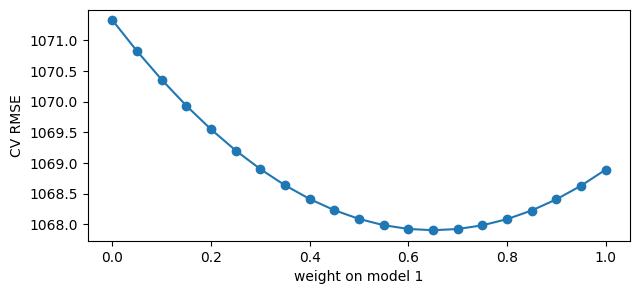

0.50    1068.085
0.60    1067.922
0.65    1067.901
0.70    1067.920
0.80    1068.081
1.00    1068.889
dtype: float64


In [27]:
lin = (oof["lin_a25"] + oof["lin_a40"]) / 2
trees = (oof["cat_raw"] + oof["xgb_raw"]) / 2
ws = np.linspace(0, 1, 21)
curve = pd.Series([rmse(y, w * lin + (1 - w) * trees) for w in ws], index=ws.round(2))
plt.figure(figsize=(7, 3))
plt.plot(curve.index, curve.values, marker="o")
plt.xlabel("weight on model 1")
plt.ylabel("CV RMSE")
plt.show()
print(curve.loc[[0.5, 0.6, 0.65, 0.7, 0.8, 1.0]].round(3))

Anywhere from 60% to 70% on model 1 gives the same score to within about 0.02, so the exact split doesn't matter. Model 1 alone (weight 1.0) is about 1 point worse, so the trees do add something.

In [28]:
# how much the public leaderboard (about half the test set) can move by chance
rng = np.random.default_rng(0)
halves = [rmse(y[i], blend_oof[i]) for i in (rng.choice(len(y), 852, replace=False) for _ in range(2000))]
print(f"RMSE on random 852-row subsets: mean {np.mean(halves):.1f}, std {np.std(halves):.1f}, "
      f"5th-95th pct {np.percentile(halves, 5):.0f} to {np.percentile(halves, 95):.0f}")

RMSE on random 852-row subsets: mean 1068.0, std 36.6, 5th-95th pct 1009 to 1131


A standard deviation of about 36 on 852 rows means differences of a point or two on the public leaderboard are mostly luck. I chose everything above by CV.

## Submission

In [29]:
final = np.clip(sum(w * preds[k] for k, w in W.items()), 0, None)
sub[TARGET] = final
sub.to_csv("submission.csv", index=False)
print(sub.shape, (sub.id == pd.read_csv(f"{DATA}/sample_submission.csv").id).all())
sub.describe().round(1)

(1705, 2) True


,total_sales
count,1705.0
mean,2192.1
std,1309.2
min,103.7
25%,1183.9
50%,2064.9
75%,3057.0
max,6783.0


## Experiments that didn't make the final model

Everything here uses the same folds as above, so the numbers are directly comparable. None of it changes the submission file.

In [30]:
def cv_oof(fit_fn):
    out = np.zeros(len(train))
    for s in SEEDS:
        for tr, va in KFold(FOLDS, shuffle=True, random_state=s).split(train):
            out[va] += fit_fn(tr, va, s) / len(SEEDS)
    return out

price = X["product_price"].values
exp = {"final blend (reference)": rmse(y, blend_oof), "model 1 alone, alpha 40 (reference)": rmse(y, oof["lin_a40"])}

def cat_with_target(fwd, inv):
    def fit(tr, va, s):
        m = CatBoostRegressor(iterations=5000, learning_rate=0.03, depth=6, l2_leaf_reg=5, random_seed=s,
                              verbose=0, od_type="Iter", od_wait=300)
        m.fit(X.iloc[tr], fwd(y[tr], price[tr]), cat_features=CATS, eval_set=(X.iloc[va], fwd(y[va], price[va])))
        return inv(m.predict(X.iloc[va]), price[va])
    return fit

exp["CatBoost, sqrt target"] = rmse(y, cv_oof(cat_with_target(lambda v, p: np.sqrt(v), lambda v, p: np.square(v))))
cat_pp_oof = cv_oof(cat_with_target(lambda v, p: v / p, lambda v, p: v * p))
exp["CatBoost, sales/price target"] = rmse(y, cat_pp_oof)
exp["blend with sales/price CatBoost instead of raw"] = rmse(y, 0.65 * (oof["lin_a25"] + oof["lin_a40"]) / 2
                                                            + 0.35 * (cat_pp_oof + oof["xgb_raw"]) / 2)
exp["CatBoost, raw target (reference)"] = rmse(y, oof["cat_raw"])
pd.Series(exp).round(3)

final blend (reference)                           1067.901
model 1 alone, alpha 40 (reference)               1068.925
CatBoost, sqrt target                             1077.894
CatBoost, sales/price target                      1070.411
blend with sales/price CatBoost instead of raw    1068.182
CatBoost, raw target (reference)                  1071.153
dtype: float64

In [31]:
from lightgbm import LGBMRegressor, early_stopping

def lgb_fit(tr, va, s):
    m = LGBMRegressor(n_estimators=10000, learning_rate=0.01, num_leaves=15, min_child_samples=40, subsample=0.8,
                      subsample_freq=1, colsample_bytree=0.7, reg_lambda=5, random_state=s, verbose=-1)
    m.fit(Xc.iloc[tr][XGB_FEATS], y[tr], eval_set=[(Xc.iloc[va][XGB_FEATS], y[va])],
          callbacks=[early_stopping(300, verbose=False)])
    return m.predict(Xc.iloc[va][XGB_FEATS])

lgb_oof = cv_oof(lgb_fit)
exp["LightGBM"] = rmse(y, lgb_oof)
exp["blend with LightGBM added to the trees"] = rmse(y, 0.65 * lin + 0.35 * (oof["cat_raw"] + oof["xgb_raw"] + lgb_oof) / 3)
pd.Series(exp).round(3)

final blend (reference)                           1067.901
model 1 alone, alpha 40 (reference)               1068.925
CatBoost, sqrt target                             1077.894
CatBoost, sales/price target                      1070.411
blend with sales/price CatBoost instead of raw    1068.182
CatBoost, raw target (reference)                  1071.153
LightGBM                                          1075.982
blend with LightGBM added to the trees            1068.061
dtype: float64

In [32]:
def model1_variant(tr_idx, alpha=40, extra=None, extra_alpha=100, pool=0.0):
    d = train.iloc[tr_idx].assign(product_category=lambda f: f.product_category.str.title())
    p = d.product_code.map(TRUE_PRICE).values
    u = d.total_sales.values / p
    k = pd.Series(u).groupby(d.store_code.values).mean()
    if pool:
        fmt = d.groupby("store_code").store_format.first()
        k = (1 - pool) * k + pool * fmt.map(pd.Series(u).groupby(d.store_format.values).mean())
    base = d.store_code.map(k).values
    extra_eff = None
    if extra:
        g = pd.Series(u / base - 1).groupby(d[extra].values).agg(["sum", "count"])
        extra_eff = g["sum"] / (g["count"] + extra_alpha)
        base = base * (1 + d[extra].map(extra_eff).values)
    g = pd.Series(u / base - 1).groupby(d.product_code.values).agg(["sum", "count"])
    eff = g["sum"] / (g["count"] + alpha)

    def predict(f):
        f = f.assign(product_category=lambda x: x.product_category.str.title())
        out = f.store_code.map(k).values * f.product_code.map(TRUE_PRICE).values * (1 + f.product_code.map(eff).fillna(0).values)
        if extra:
            out = out * (1 + f[extra].map(extra_eff).fillna(0).values)
        return out
    return predict

for col in ["product_category", "fat_content"]:
    exp[f"model 1 + {col} multiplier"] = rmse(y, cv_oof(lambda tr, va, s: model1_variant(tr, extra=col)(train.iloc[va])))
for pool in [0.25, 0.5]:
    exp[f"model 1, store average pulled {int(pool * 100)}% towards format average"] = rmse(
        y, cv_oof(lambda tr, va, s: model1_variant(tr, pool=pool)(train.iloc[va])))
pd.Series(exp).round(3)

final blend (reference)                                     1067.901
model 1 alone, alpha 40 (reference)                         1068.925
CatBoost, sqrt target                                       1077.894
CatBoost, sales/price target                                1070.411
blend with sales/price CatBoost instead of raw              1068.182
CatBoost, raw target (reference)                            1071.153
LightGBM                                                    1075.982
blend with LightGBM added to the trees                      1068.061
model 1 + product_category multiplier                       1070.928
model 1 + fat_content multiplier                            1069.086
model 1, store average pulled 25% towards format average    1068.993
model 1, store average pulled 50% towards format average    1069.318
dtype: float64

In [33]:
FE_R = ["product_price", "store_code", "product_code", "product_category", "shelf_visibility", "product_weight_kg", "fat_content"]

def residual_fit(tr, va, s):
    base = structural_model(tr, 10 ** 9)
    m = CatBoostRegressor(iterations=500, learning_rate=0.02, depth=4, l2_leaf_reg=30, random_seed=s, verbose=0)
    m.fit(X.iloc[tr][FE_R], y[tr] - base(train.iloc[tr]),
          cat_features=["store_code", "product_code", "product_category", "fat_content"])
    return base(train.iloc[va]) + m.predict(X.iloc[va][FE_R])

res_oof = cv_oof(residual_fit)
exp["CatBoost on residuals of store units x price"] = rmse(y, res_oof)
exp["blend with the residual model added to the trees"] = rmse(y, 0.65 * lin + 0.35 * (trees + res_oof) / 2)
summary = pd.Series(exp).round(3).sort_values()
summary

final blend (reference)                                     1067.901
blend with LightGBM added to the trees                      1068.061
blend with sales/price CatBoost instead of raw              1068.182
blend with the residual model added to the trees            1068.424
model 1 alone, alpha 40 (reference)                         1068.925
model 1, store average pulled 25% towards format average    1068.993
model 1 + fat_content multiplier                            1069.086
model 1, store average pulled 50% towards format average    1069.318
CatBoost, sales/price target                                1070.411
model 1 + product_category multiplier                       1070.928
CatBoost, raw target (reference)                            1071.153
CatBoost on residuals of store units x price                1071.216
LightGBM                                                    1075.982
CatBoost, sqrt target                                       1077.894
dtype: float64

Nothing here beats the final blend.
- A sqrt target hurts CatBoost badly. The sales/price target is better than the raw target on its own, but swapping it into the blend makes the blend slightly worse (1068.18 vs 1067.90), so I kept the raw version.
- LightGBM is the weakest tree model, and adding it to the blend makes things slightly worse.
- Category and fat-content multipliers make model 1 worse. So does pulling each store's average towards its format average, which suggests the store differences are real.
- A CatBoost fitted on the residuals of store units × price is no better than plain CatBoost, and it doesn't help the blend.

## Result

- CV RMSE of the final blend: 1067.90 (5-fold, 3 shuffles).
- The file this notebook writes on my machine scored 1068.58 on the public leaderboard.
- Run on Kaggle, the same notebook writes a slightly different file (XGBoost differs between platforms, see the setup note), which scored 1068.69. Given how much the public score moves by chance (see the check above), the two are equivalent.